------------------------------------------------------------------
Data Elements

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 

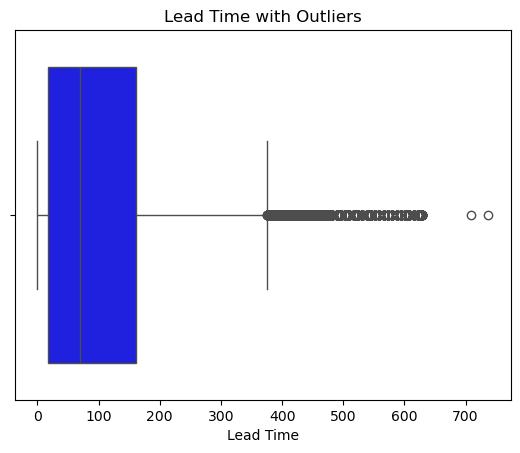

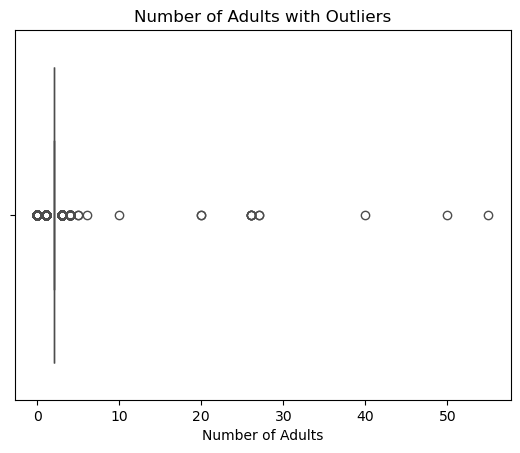

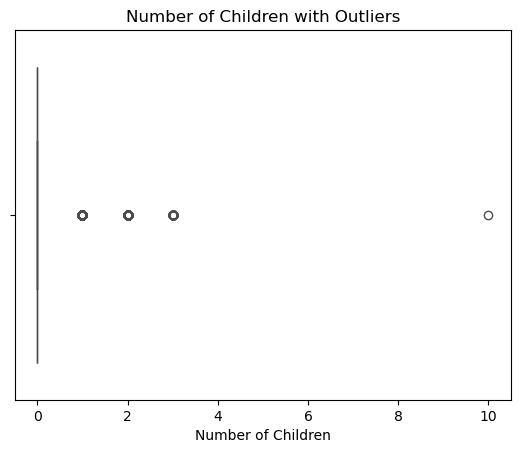

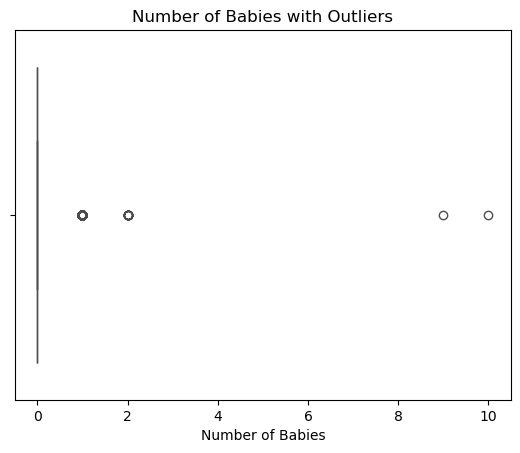

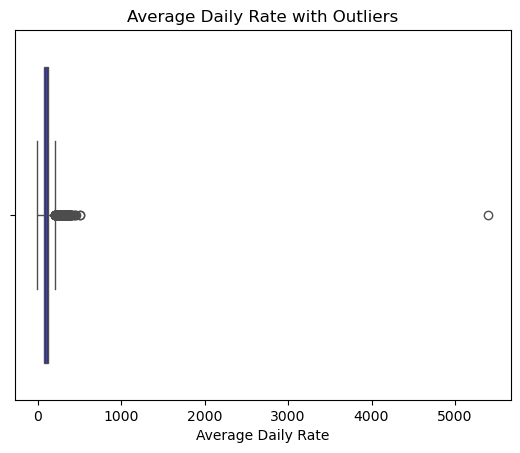

------------------------------------------------------------------

Hotel Category



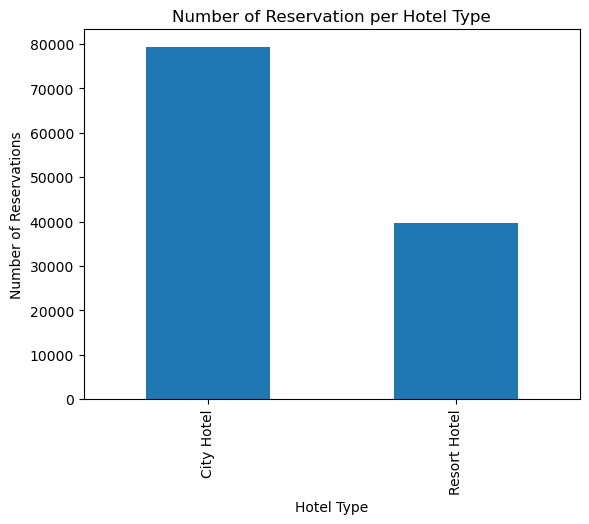

Cancelled



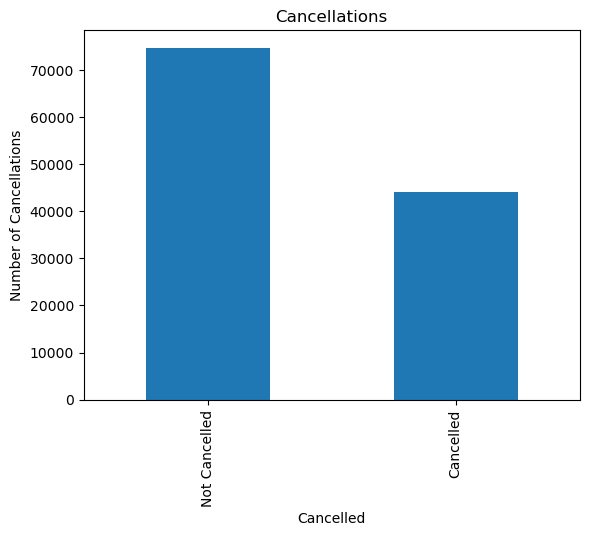

------------------------------------------------------------------

Cancellations by Hotel Type



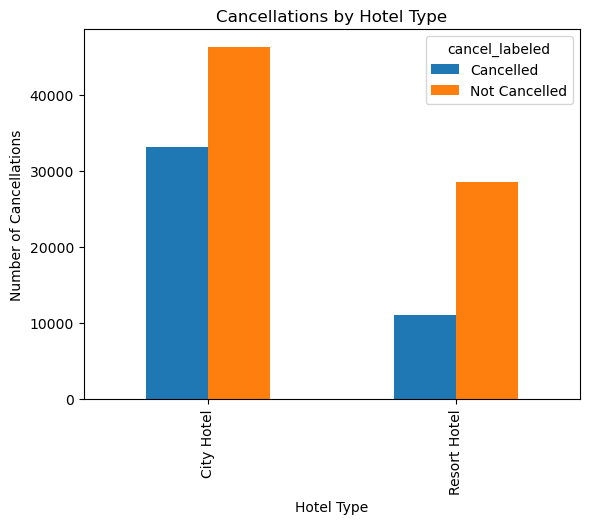

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/thoskin1/COSC526/refs/heads/main/Final_Project/hotel_booking.csv"

# Load the latest version
df = pd.read_csv(URL)

print("------------------------------------------------------------------")
print("Data Elements")
print()
print(df.info())
print()

print("------------------------------------------------------------------")
print("Five Five Rows")
print()
print(df.head())
print()

print("------------------------------------------------------------------")
print("Missing Data")
print()
print(df.isnull().sum())
print()

# Remove columns and missing data.
drop_columns = ['name', 'email', 'phone-number', 'credit_card', 'agent', 'company']
df.drop(drop_columns, axis=1, inplace=True)
df.dropna(inplace=True)

# Change reservation_status_date to date/time
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

print("------------------------------------------------------------------")
print("Statistical Description of Numerical Data")
print()
print(df.describe())
print()

print("------------------------------------------------------------------")
print("Statistical Description of Object Data")
print()
print(df.describe(include='object'))
print()

print("------------------------------------------------------------------")
# outlier detection for lead_time, adults, children, babies, adr
sns.boxplot(x=df['lead_time'], color='blue')
plt.title('Lead Time with Outliers')
plt.xlabel('Lead Time')
plt.show()

sns.boxplot(x=df['adults'], color='blue')
plt.title('Number of Adults with Outliers')
plt.xlabel('Number of Adults')
plt.show()

sns.boxplot(x=df['children'], color='blue')
plt.title('Number of Children with Outliers')
plt.xlabel('Number of Children')
plt.show()

sns.boxplot(x=df['babies'], color='blue')
plt.title('Number of Babies with Outliers')
plt.xlabel('Number of Babies')
plt.show()

sns.boxplot(x=df['adr'], color='blue')
plt.title('Average Daily Rate with Outliers')
plt.xlabel('Average Daily Rate')
plt.show()

#remove outlier from average daily rate.
df = df[df['adr'] < 5000]

print("------------------------------------------------------------------")
print()

print("Hotel Category")
print()
df['hotel'].value_counts().plot(kind='bar')
plt.title("Number of Reservation per Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Reservations")
plt.show()

print("Cancelled")
print()
cancel_map = {0: 'Not Cancelled', 1: 'Cancelled'}
df['cancel_labeled'] = df['is_canceled'].map(cancel_map)
df['cancel_labeled'].value_counts().plot(kind='bar')
plt.title("Cancellations")
plt.xlabel("Cancelled")
plt.ylabel("Number of Cancellations")
plt.show()

print("------------------------------------------------------------------")
print()
print("Cancellations by Hotel Type")
print()

grouped = df.groupby(['hotel', 'cancel_labeled']).size().unstack()
grouped.plot(kind='bar')
plt.title('Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Cancellations')
plt.show()
